# Collaboration and Competition — MADDPG

Melhorias em relação à versão anterior (`Tennis_02`):
- **MADDPG**: cada agente tem seu próprio Ator e Crítico centralizado (recebe obs+ações de todos)
- **Decay de ruído**: escala do OUNoise decai a cada episódio
- **TAU reduzido**: 1e-2 → 1e-3 (atualizações de target mais suaves)
- **Updates/step reduzido**: 4 → 2 (menos risco de overfitting)

In [ ]:
# !pip install .
# !pip install protobuf==3.20.3

In [1]:
import google.protobuf
print(google.protobuf.__version__)

3.20.3


In [2]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from collections import deque
from unityagents import UnityEnvironment

## 1. Inicializar o Ambiente

In [3]:
env = UnityEnvironment(file_name="Tennis_Windows_x86_64/Tennis.exe")

INFO:unityagents:
'Academy' started successfully!
Unity Academy name: Academy
        Number of Brains: 1
        Number of External Brains : 1
        Lesson number : 0
        Reset Parameters :
		
Unity brain name: TennisBrain
        Number of Visual Observations (per agent): 0
        Vector Observation space type: continuous
        Vector Observation space size (per agent): 8
        Number of stacked Vector Observation: 3
        Vector Action space type: continuous
        Vector Action space size (per agent): 2
        Vector Action descriptions: , 


In [4]:
brain_name = env.brain_names[0]
brain = env.brains[brain_name]

env_info = env.reset(train_mode=True)[brain_name]

num_agents  = len(env_info.agents)
action_size = brain.vector_action_space_size
state_size  = env_info.vector_observations.shape[1]

print(f'Agentes : {num_agents}')
print(f'Ações   : {action_size}')
print(f'Estados : {state_size}')

Agentes : 2
Ações   : 2
Estados : 24


## 2. Instanciar o Agente MADDPG

In [5]:
from maddpg_agent import MADDPGAgent

agent = MADDPGAgent(
    state_size=state_size,
    action_size=action_size,
    num_agents=num_agents,
    random_seed=0
)

## 3. Loop de Treinamento

In [6]:
def maddpg(n_episodes=3000, max_t=1000, print_every=100, target_score=0.5):
    scores_deque = deque(maxlen=100)
    scores_hist  = []

    for i_episode in range(1, n_episodes + 1):
        env_info = env.reset(train_mode=True)[brain_name]
        states   = env_info.vector_observations          # (num_agents, state_size)
        scores   = np.zeros(num_agents)
        agent.reset()

        for t in range(max_t):
            actions    = agent.act(states)
            env_info   = env.step(actions)[brain_name]
            next_states = env_info.vector_observations
            rewards    = env_info.rewards
            dones      = env_info.local_done

            agent.step(
                states,
                actions,
                np.array(rewards),
                next_states,
                np.array(dones, dtype=np.float32)
            )

            states  = next_states
            scores += rewards

            if np.any(dones):
                break

        # Critério Udacity: maior score entre os dois agentes
        episode_score = float(np.max(scores))
        scores_deque.append(episode_score)
        scores_hist.append(episode_score)

        # Decair ruído ao final de cada episódio
        agent.decay_noise()

        if i_episode % print_every == 0:
            print(f'Episode {i_episode}\tAvg(100): {np.mean(scores_deque):.3f}'
                  f'\tNoise scale: {agent.noise_scale:.4f}')

        if np.mean(scores_deque) >= target_score:
            print(f'\nAmbiente resolvido no episódio {i_episode}!'
                  f' Média: {np.mean(scores_deque):.3f}')
            agent.save('checkpoint_maddpg')
            break

    return scores_hist

In [7]:
scores = maddpg()

Episode 100	Avg(100): 0.006	Noise scale: 0.9512
Episode 200	Avg(100): 0.010	Noise scale: 0.9048
Episode 300	Avg(100): 0.005	Noise scale: 0.8607
Episode 400	Avg(100): 0.009	Noise scale: 0.8187
Episode 500	Avg(100): 0.036	Noise scale: 0.7788
Episode 600	Avg(100): 0.047	Noise scale: 0.7408
Episode 700	Avg(100): 0.071	Noise scale: 0.7046
Episode 800	Avg(100): 0.163	Noise scale: 0.6703
Episode 900	Avg(100): 0.201	Noise scale: 0.6376
Episode 1000	Avg(100): 0.377	Noise scale: 0.6065

Ambiente resolvido no episódio 1077! Média: 0.509


## 4. Visualizar Resultados

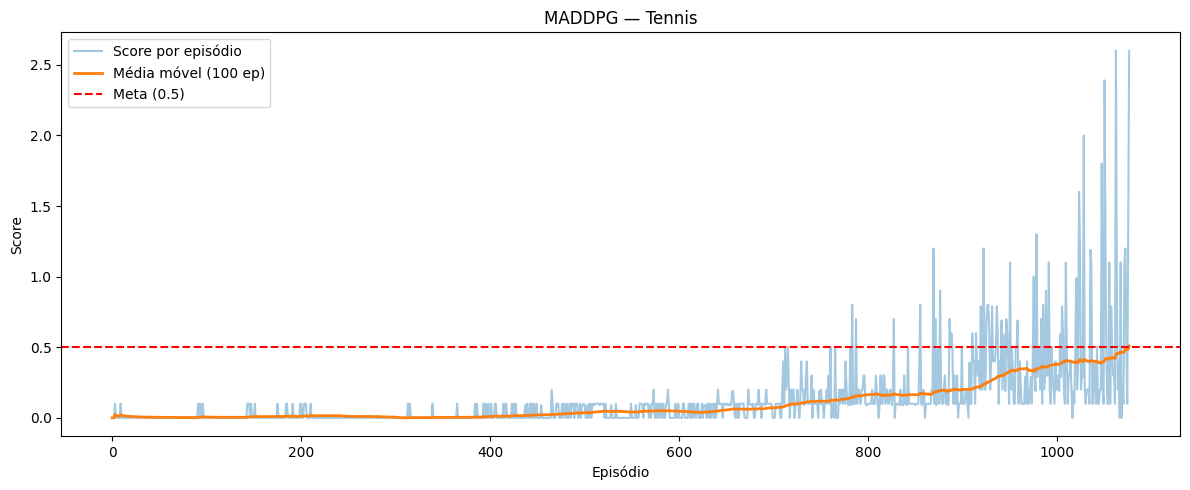

In [8]:
rolling_avg = [np.mean(scores[max(0, i-99):i+1]) for i in range(len(scores))]

plt.figure(figsize=(12, 5))
plt.plot(scores, alpha=0.4, label='Score por episódio')
plt.plot(rolling_avg, linewidth=2, label='Média móvel (100 ep)')
plt.axhline(y=0.5, color='r', linestyle='--', label='Meta (0.5)')
plt.xlabel('Episódio')
plt.ylabel('Score')
plt.title('MADDPG — Tennis')
plt.legend()
plt.tight_layout()
plt.savefig('rewards_plot_maddpg.png', dpi=150)
plt.show()

In [ ]:
env.close()